In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from scipy.stats import ks_2samp

In [2]:
# %run Shuffle.py

In [3]:
results_run_ref = pd.read_csv("../Results_hubs_activity_stats.tsv", sep="\t")
results_run_ref.set_index('OLN', inplace=True)
df = pd.read_csv("./results/tf_summary_all_conditions.csv")
# heat = df.pivot(index='TF', columns='condition', values='z_score')

In [4]:
df_signif=df[df['TF'].isin(results_run_ref[results_run_ref['Groups'].notna()].index)]

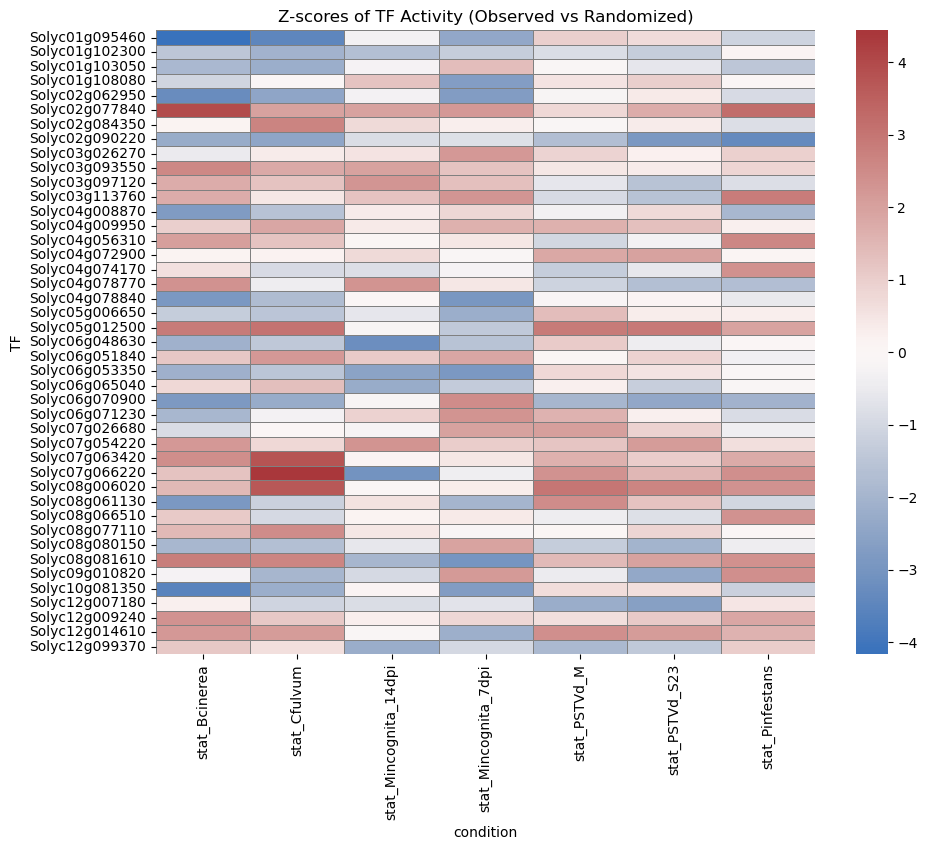

In [5]:
heat = df_signif.pivot(index='TF', columns='condition', values='z_score')

plt.figure(figsize=(10, len(heat) * 0.2))
sns.heatmap(heat, center=0, cmap="vlag", linewidths=0.5, linecolor='gray')
plt.title("Z-scores of TF Activity (Observed vs Randomized)")
plt.tight_layout()
plt.show()

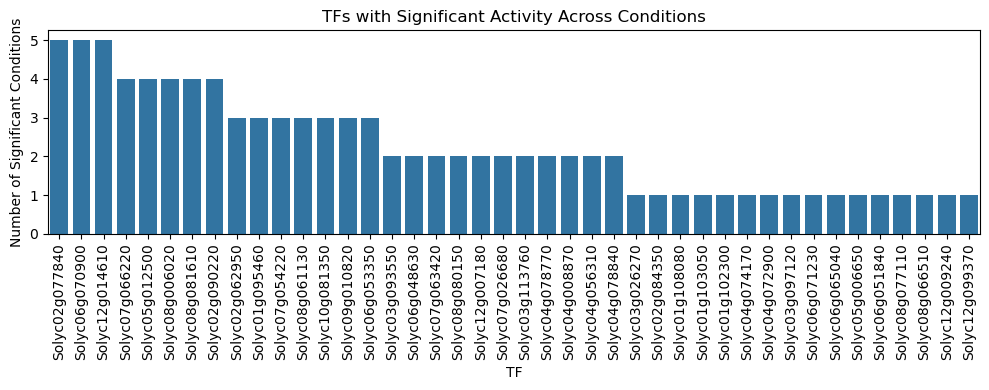

In [6]:
sig_count = df[df['significant']].groupby('TF')['condition'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=sig_count.index, y=sig_count.values)
plt.xticks(rotation=90)
plt.ylabel("Number of Significant Conditions")
plt.title("TFs with Significant Activity Across Conditions")
plt.tight_layout()
plt.show()

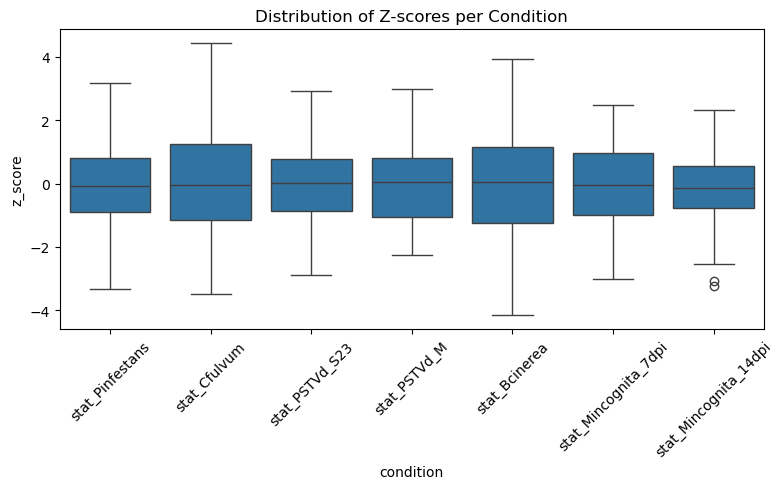

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='condition', y='z_score', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Z-scores per Condition")
plt.tight_layout()
plt.show()

In [8]:
# results = pd.read_csv('../TDA/Results_hubs_activity_stats_mega_cluster-SUPP_table.tsv', sep='\t')
results = results_run_ref[results_run_ref.index.isin(heat.index)]
pval = results.loc[:,'Pinfestans_pval':'Mincognita_14dpi_pval']
pval = pval <= 0.05
pval = pval[sorted(pval.columns)]

In [9]:
heat_pval_emp = df.pivot(index='TF', columns='condition', values='significant')
heat_pval_emp = heat_pval_emp[heat_pval_emp.index.isin(heat.index)]

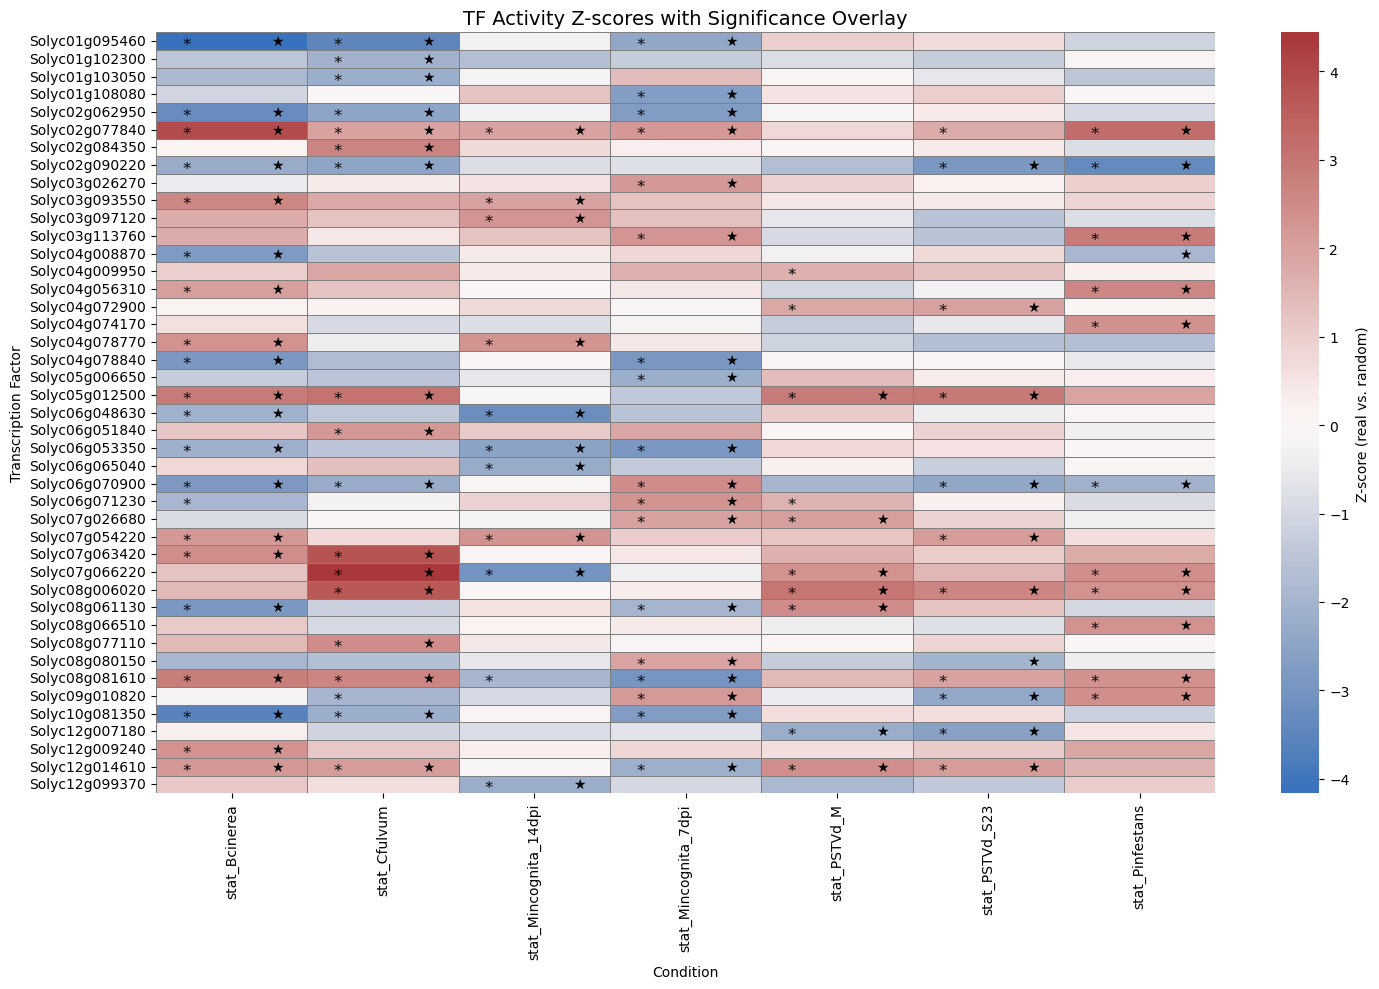

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

bool_cond = []
# Example: z_score_df and significance_df should have the same shape and matching index/columns

plt.figure(figsize=(15, 10))

# Create the heatmap of z-scores
ax = sns.heatmap(
    heat,
    cmap="vlag", center=0,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Z-score (real vs. random)'}
)

# Overlay stars for significance (adjust fontsize/style as needed)
for y in range(heat.shape[0]):
    for x in range(heat.shape[1]):
        if pval.iloc[y, x]:
            ax.text(x + 0.2, y + 0.7, '*', color='black',
                    ha='center', va='center', fontsize=12)
            
for y in range(heat.shape[0]):
    for x in range(heat.shape[1]):
        if heat_pval_emp.iloc[y, x]:
            ax.text(x + 0.8, y + 0.5, '★', color='black',
                    ha='center', va='center', fontsize=10)
            
for y in range(heat.shape[0]):
    for x in range(heat.shape[1]):
        bool_cond.append(pval.iloc[y, x] and heat_pval_emp.iloc[y, x])
            

plt.title("TF Activity Z-scores with Significance Overlay", fontsize=14)
plt.xlabel("Condition")
plt.ylabel("Transcription Factor")
plt.tight_layout()
# plt.savefig('./Heatmap_shuffle_zscore_with_significance.svg', format='svg')
plt.show()

In [11]:
heat_pval_emp.columns = pval.columns
res_bool_shuffle = heat_pval_emp & pval

In [12]:
bool_cond.count(True) == res_bool_shuffle.sum().sum()

True

In [13]:
import numpy as np

In [14]:
res_bool_shuffle

,Bcinerea_pval,Cfulvum_pval,Mincognita_14dpi_pval,Mincognita_7dpi_pval,PSTVd_M_pval,PSTVd_S23_pval,Pinfestans_pval
TF,,,,,,,
Solyc01g095460,True,True,False,True,False,False,False
Solyc01g102300,False,True,False,False,False,False,False
Solyc01g103050,False,True,False,False,False,False,False
Solyc01g108080,False,False,False,True,False,False,False
Solyc02g062950,True,True,False,True,False,False,False
Solyc02g077840,True,True,True,True,False,False,True
Solyc02g084350,False,True,False,False,False,False,False
Solyc02g090220,True,True,False,False,False,True,True
Solyc03g026270,False,False,False,True,False,False,False


In [15]:
res_bool_shuffle.sum().sum()

92

In [27]:
res_bool_shuffle[res_bool_shuffle.any(axis=1)]

,Bcinerea_pval,Cfulvum_pval,Mincognita_14dpi_pval,Mincognita_7dpi_pval,PSTVd_M_pval,PSTVd_S23_pval,Pinfestans_pval,Groups_corrected
TF,,,,,,,,
Solyc01g095460,True,True,False,True,False,False,False,Bcinerea_pval & Cfulvum_pval & Mincognita_7dpi...
Solyc01g102300,False,True,False,False,False,False,False,Cfulvum_pval
Solyc01g103050,False,True,False,False,False,False,False,Cfulvum_pval
Solyc01g108080,False,False,False,True,False,False,False,Mincognita_7dpi_pval
Solyc02g062950,True,True,False,True,False,False,False,Bcinerea_pval & Cfulvum_pval & Mincognita_7dpi...
Solyc02g077840,True,True,True,True,False,False,True,Bcinerea_pval & Cfulvum_pval & Mincognita_14dp...
Solyc02g084350,False,True,False,False,False,False,False,Cfulvum_pval
Solyc02g090220,True,True,False,False,False,True,True,Bcinerea_pval & Cfulvum_pval & PSTVd_S23_pval ...
Solyc03g026270,False,False,False,True,False,False,False,Mincognita_7dpi_pval


In [16]:
def get_groups(row):
    groups = []
    cols = res_bool_shuffle.columns
    for col in cols:
        if row[col] == True:
            groups.append(col)
    return ' & '.join(groups) if groups else None
res_bool_shuffle['Groups_corrected'] = res_bool_shuffle.apply(get_groups, axis=1)

In [17]:
res_bool_shuffle

,Bcinerea_pval,Cfulvum_pval,Mincognita_14dpi_pval,Mincognita_7dpi_pval,PSTVd_M_pval,PSTVd_S23_pval,Pinfestans_pval,Groups_corrected
TF,,,,,,,,
Solyc01g095460,True,True,False,True,False,False,False,Bcinerea_pval & Cfulvum_pval & Mincognita_7dpi...
Solyc01g102300,False,True,False,False,False,False,False,Cfulvum_pval
Solyc01g103050,False,True,False,False,False,False,False,Cfulvum_pval
Solyc01g108080,False,False,False,True,False,False,False,Mincognita_7dpi_pval
Solyc02g062950,True,True,False,True,False,False,False,Bcinerea_pval & Cfulvum_pval & Mincognita_7dpi...
Solyc02g077840,True,True,True,True,False,False,True,Bcinerea_pval & Cfulvum_pval & Mincognita_14dp...
Solyc02g084350,False,True,False,False,False,False,False,Cfulvum_pval
Solyc02g090220,True,True,False,False,False,True,True,Bcinerea_pval & Cfulvum_pval & PSTVd_S23_pval ...
Solyc03g026270,False,False,False,True,False,False,False,Mincognita_7dpi_pval


In [18]:
results_run_ref

,gene.description,gene.family,Gene_Name,stats_Pinfestans,stats_Cfulvum,stats_PSTVd_S23,stats_PSTVd_M,stats_Bcinerea,stats_Mincognita_7dpi,stats_Mincognita_14dpi,...,Mincognita_7dpi_acts,Mincognita_14dpi_acts,Pinfestans_pval,Cfulvum_pval,PSTVd_S23_pval,PSTVd_M_pval,Bcinerea_pval,Mincognita_7dpi_pval,Mincognita_14dpi_pval,Groups
OLN,,,,,,,,,,,,,,,,,,,,,
Solyc00g014850,orf86 (mitochondrion) (AHRD V3.3 *** YP_002608...,NaN,mRNA:Solyc00g014850.1.1,1.536888,1.789339,4.409710,3.727931,-0.578172,-1.125662,-3.183436,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc00g020040,Cytochrome c biogenesis B (AHRD V3.3 *** A0A0C...,NaN,mRNA:Solyc00g020040.1.1,4.040848,1.996285,1.082374,0.831667,1.254339,0.966556,-0.591382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc00g020020,Unknown protein,NaN,mRNA:Solyc00g020020.2.1,2.551153,4.777814,2.732673,3.979805,1.978838,4.528237,-1.549161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc00g020010,Unknown protein,NaN,mRNA:Solyc00g020010.1.1,1.953473,4.407855,2.275619,3.173782,2.697454,-0.924195,0.730795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc00g019950,NADH dehydrogenase subunit 9 (AHRD V3.11 *** t...,NaN,mRNA:Solyc00g019950.2.1,0.644474,3.884225,1.044472,0.169913,0.781690,1.984675,3.664932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Solyc09g065930,transmembrane protein Chr2:17509933-17512898 R...,NaN,mRNA:Solyc09g065930.5.1,-1.988150,2.305436,-0.454501,-1.139960,-0.390191,-2.782308,2.254541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc09g072970,U6 snRNA-associated Sm-like protein LSm2 (AHRD...,NaN,mRNA:Solyc09g072970.3.1,-0.451018,2.166909,0.601795,0.582783,-0.390859,-3.441385,3.611005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solyc09g074260,Leucine-rich repeat receptor-like kinase (AHRD...,NaN,mRNA:Solyc09g074260.1.1,-12.026359,-4.007545,-1.597959,-1.936589,-10.369173,-1.308699,0.113801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
results_corrected = pd.merge(results_run_ref, res_bool_shuffle[['Groups_corrected']], left_index=True, right_index=True, how='left')

In [20]:
results_corrected.to_csv('../Results_hubs_activity_stats_shuffle_corrected.tsv', sep='\t')

## Violin Plot

In [21]:
pval_violin = pval.reset_index().melt(id_vars='OLN', var_name='condition', value_name='significant')
pval_violin['condition'] = pval_violin['condition'].str.replace('_pval','')

In [22]:
real_score = pd.read_csv("./results/real_activity_all_conditions.csv")
randomized_score = pd.read_csv("./results/null_distribution_all_conditions.csv")
real_score['type']='real'
randomized_score['type']='random'

In [23]:
df_all = pd.concat([real_score[['source','condition','score','type']],randomized_score[['source','condition','score','type']]], ignore_index=True)
df_all['condition'] = df_all['condition'].str.replace('stat_','')
df_all = df_all.merge(pval_violin, left_on=['source', 'condition'], right_on=['OLN', 'condition'])
df_signif_all = df_all[df_all['significant']]
df_signif_all = df_signif_all.sort_values(by=['condition','source'])

In [24]:
# plt.figure(figsize=(14, 6))
# sns.violinplot(
#     data=df_signif_all,
#     x='condition',
#     y='score',
#     hue='type',
#     split=False,
#     inner='quartile',
#     palette='Set2'
# )

# plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
# plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
# plt.ylabel("TF Activity Score (ULM)")
# plt.xlabel("Condition")
# plt.legend(title="GRN Type")
# plt.tight_layout()
# plt.savefig('./Violin_shuffle_activity.svg', format='svg')
# plt.show()

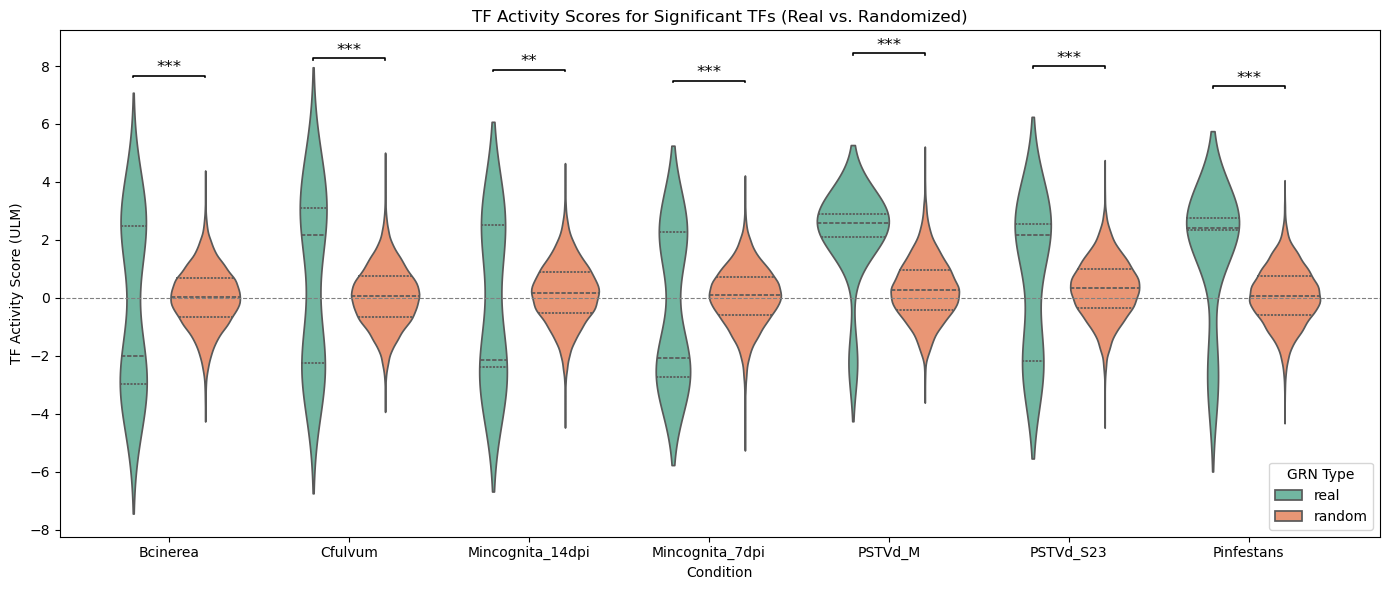

In [25]:
# --- Run KS tests per condition ---
ks_results = []
for cond in df_signif_all['condition'].unique():
    real_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'real')]['score']
    rand_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'random')]['score']
    stat, pval = ks_2samp(real_vals, rand_vals)
    ks_results.append({"condition": cond, "KS_statistic": stat, "p_value": pval})

ks_df = pd.DataFrame(ks_results)

# --- Map p-values to stars ---
def significance_label(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

# --- Plot violin ---
plt.figure(figsize=(14, 6))
ax = sns.violinplot(
    data=df_signif_all,
    x='condition',
    y='score',
    hue='type',
    split=False,
    inner='quartile',
    palette='Set2'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
plt.ylabel("TF Activity Score (ULM)")
plt.xlabel("Condition")
plt.legend(title="GRN Type")

# --- Helper function to draw brackets ---
def add_stat_annotation(ax, x1, x2, y, h, text):
    """Draws a bracket between x1 and x2 at height y+h with a significance label."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1 + x2) * 0.5, y + h + 0.02, text,
            ha='center', va='bottom', color='black', fontsize=12)

# --- Add significance brackets per condition ---
for i, row in ks_df.iterrows():
    cond = row['condition']
    pval = row['p_value']
    label = significance_label(pval)

    # violinplot places two violins per condition side by side → positions are like 0,1,2... with offsets
    cond_positions = [p for p, c in enumerate(df_signif_all['condition'].unique()) if c == cond][0]

    # The two violins (real vs random) are slightly shifted left/right around cond_positions
    x1, x2 = cond_positions - 0.2, cond_positions + 0.2
    
    # Compute height for bracket
    y_max = df_signif_all[df_signif_all['condition'] == cond]['score'].max()
    add_stat_annotation(ax, x1, x2, y=y_max + 3.5, h=0.05, text=label)

plt.tight_layout()
plt.savefig('./Violin_shuffle_activity_with_brackets.svg', format='svg')
plt.show()

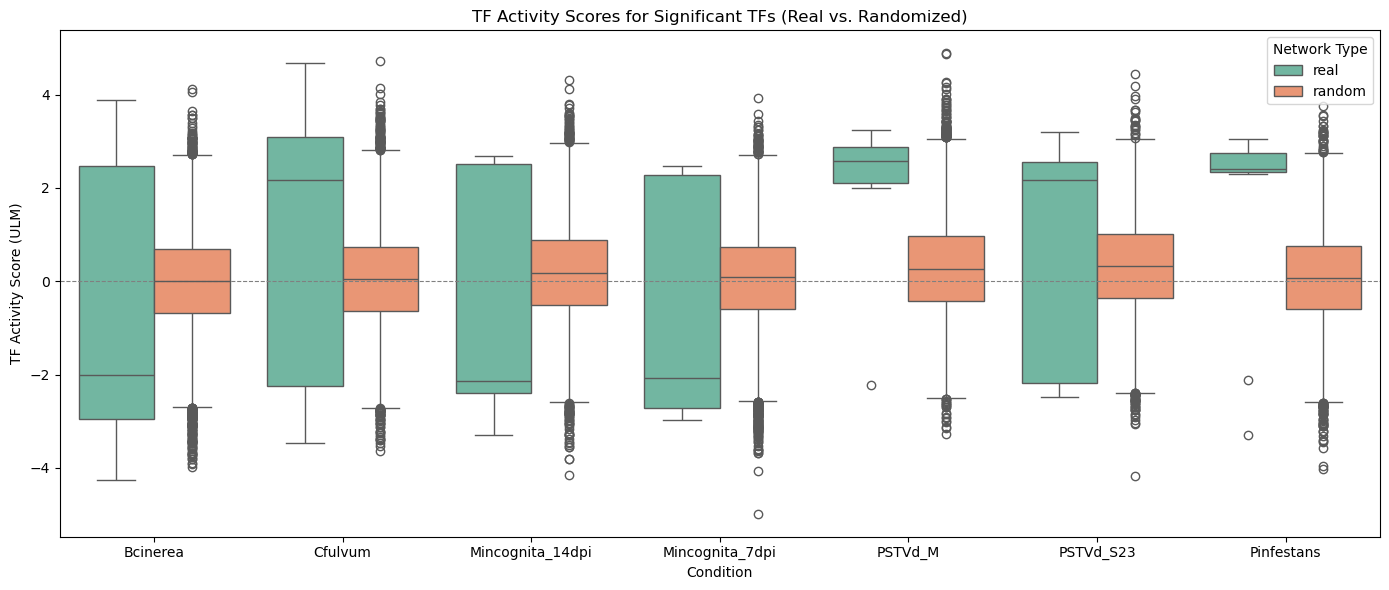

In [26]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_signif_all,
    x='condition',
    y='score',
    hue='type',
    palette='Set2'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
plt.ylabel("TF Activity Score (ULM)")
plt.xlabel("Condition")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()